Differential expression test

In [1]:

# %% Libraries
import sys
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import gdown
import gzip
import shutil
import urllib.request

from pathlib import Path
import os
import scvi


/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# %% Setting Paths
# setting paths
MAIN_DIR_NAME = "cosmx_gray"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(42)

In [3]:
# %% Load comb object 

CUR_OBJ_V = 'v8'
CUR_OBJ_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb_{CUR_OBJ_V}.h5ad'


comb = sc.read_h5ad(CUR_OBJ_PATH)

## proportions of cell types per condition per sections

### Airway Epithelium (proportions)

In [4]:
airway_epi = comb[comb.obs['ann_lvl_3'].isin(['basal', 'secretory', 'ciliated'])].copy()

In [ ]:
airway_epi.obs[['ann_lvl_3','condition']].value_counts()

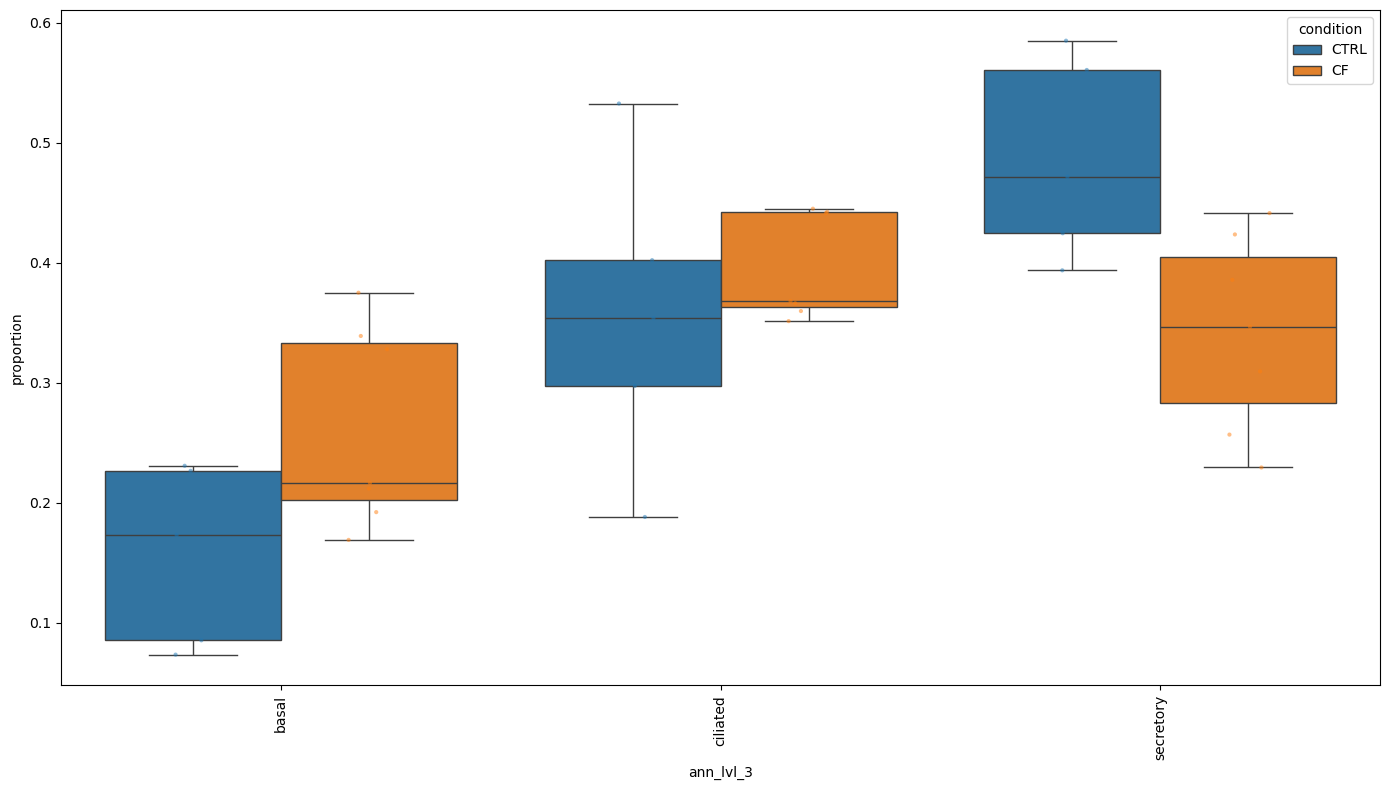

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------
# 1) Choose the AnnData object to analyze
# -------------------------
ADATA_OBJ = airway_epi  # <-- the AnnData containing obs columns: sample_name, ann_lvl_3, condition

# -------------------------
# 2) Defensive type casting
#    - Ensures groupby keys behave consistently (no categorical surprises)
# -------------------------
for col in ["sample_name", "ann_lvl_3", "condition"]:
    ADATA_OBJ.obs[col] = ADATA_OBJ.obs[col].astype(str)

# NOTE:
# You also casted in `comb.obs` earlier. That’s fine if you use `comb` elsewhere,
# but it doesn’t affect this block unless ADATA_OBJ == comb.

# -------------------------
# 3) Count cells per (sample_name x ann_lvl_3)
# -------------------------
counts = (
    ADATA_OBJ.obs
    .groupby(["sample_name", "ann_lvl_3"])
    .size()
    .unstack(fill_value=0)   # rows = sample_name, columns = ann_lvl_3, values = cell counts
)

# -------------------------
# 4) Convert counts to within-sample proportions
# -------------------------
proportions = counts.div(counts.sum(axis=1), axis=0)

# -------------------------
# 5) Add sample-level metadata (condition)
#    - drop_duplicates() assumes condition is constant per sample_name
# -------------------------
meta = (
    ADATA_OBJ.obs[["sample_name", "condition"]]
    .drop_duplicates()
    .set_index("sample_name")
)

# Optional sanity check: each sample should map to exactly one condition
# (uncomment if you want it strict)
# assert meta.index.is_unique, "Some sample_name map to multiple conditions."

# -------------------------
# 6) Join metadata to proportions safely
#    - Important fix: convert columns away from CategoricalIndex edge-cases in pandas
# -------------------------
proportions = proportions.copy()
proportions.columns = proportions.columns.astype(str)

# Join by index (sample_name)
proportions = proportions.join(meta, how="left")

# -------------------------
# 7) Reshape to long/tidy format for seaborn
# -------------------------
df_melt = (
    proportions
    .reset_index()  # brings sample_name back as a column
    .melt(
        id_vars=["sample_name", "condition"],
        var_name="ann_lvl_3",
        value_name="proportion"
    )
)

# -------------------------
# 8) Plot: boxplot + per-sample points
# -------------------------
plt.figure(figsize=(14, 8))

ax = sns.boxplot(
    data=df_melt,
    x="ann_lvl_3",
    y="proportion",
    hue="condition"
)

# Overlay points (same hue). This will create a second legend; we remove it below.
sns.stripplot(
    data=df_melt,
    x="ann_lvl_3",
    y="proportion",
    hue="condition",
    dodge=True,
    alpha=0.5,
    size=3
)

# Remove the duplicate legend produced by stripplot
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(set(df_melt["condition"]))], labels[:len(set(df_melt["condition"]))], title="condition")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### Airway Epithelium (cell density)

In [6]:
airway_epi

AnnData object with n_obs × n_vars = 235702 × 6175
    obs: 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.Membrane', 'Max.Membrane', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'SplitRatioToLocal', 'NucArea', 'NucAspectRatio', 'Circularity', 'Eccentricity', 'Perimeter', 'Solidity', 'assay_type', 'version', 'Run_Tissue_name', 'Panel', 'cellSegmentationSetId', 'cellSegmentationSetName', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'fa

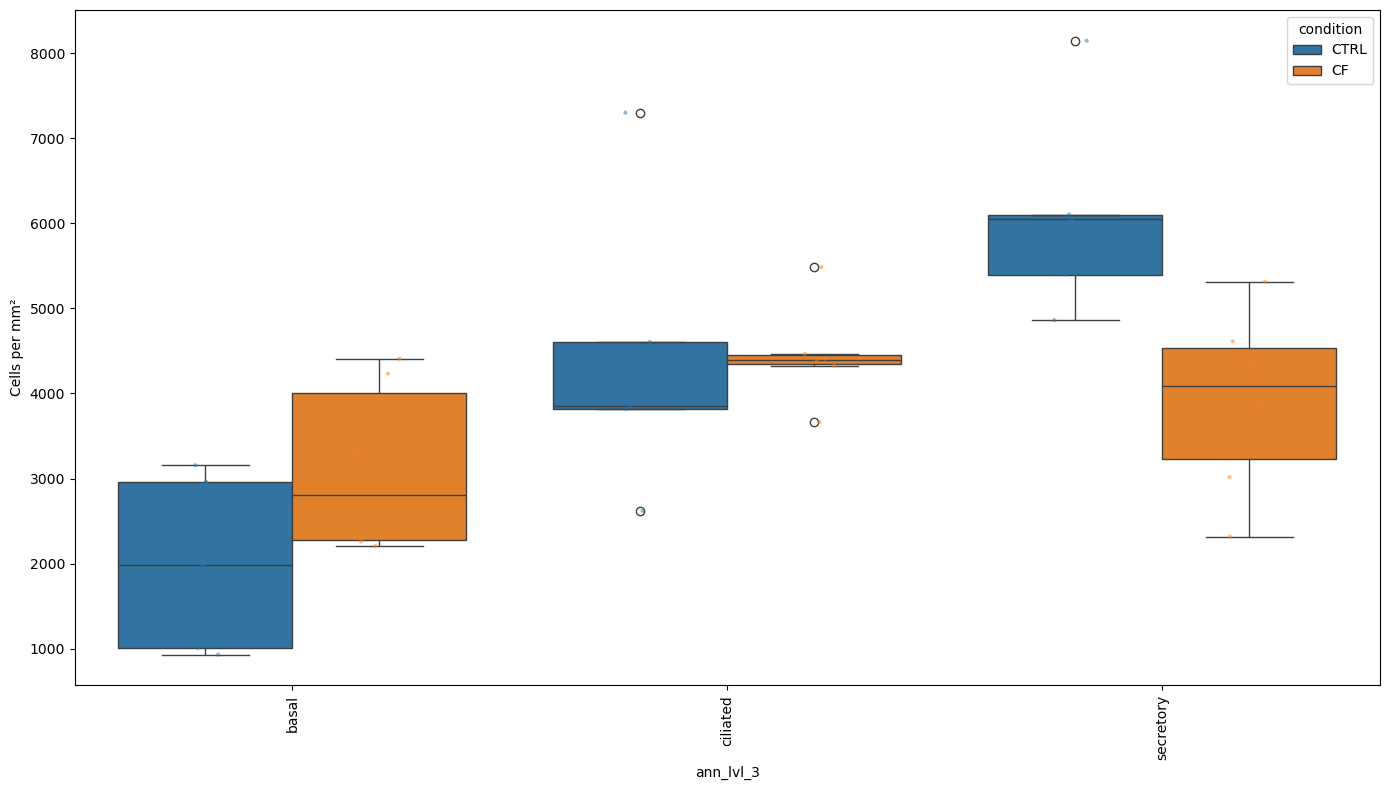

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------
# 1) Choose AnnData + define area column (µm² per cell)
# -------------------------
ADATA_OBJ = airway_epi
AREA_COL = "Area.um2"   # <-- CHANGE THIS to your per-cell area column in ADATA_OBJ.obs
SAMPLE_COL = "donor"  # <-- CHANGE THIS to your sample identifier column in ADATA_OBJ.obs
CONDITION_COL = "condition"  # <-- CHANGE THIS to your condition column in ADATA_OBJ.obs
ANN_LVL_COL = "ann_lvl_3"  # <-- CHANGE THIS to your annotation level column in ADATA_OBJ.obs

# -------------------------
# 2) Defensive type casting
# -------------------------
for col in [SAMPLE_COL, ANN_LVL_COL, CONDITION_COL]:
    ADATA_OBJ.obs[col] = ADATA_OBJ.obs[col].astype(str)

# Make sure area is numeric
ADATA_OBJ.obs[AREA_COL] = pd.to_numeric(ADATA_OBJ.obs[AREA_COL], errors="coerce")

# -------------------------
# 3) Sample-level tissue area (mm²)
#    - Sum of per-cell areas approximates "occupied tissue area"
#    - This automatically ignores lumen/empty space (no cells there)
# -------------------------
sample_area = (
    ADATA_OBJ.obs
    .groupby(SAMPLE_COL)[AREA_COL]
    .sum(min_count=1)                # min_count=1 => NaN if all missing
    .rename("area_um2_total")
    .reset_index()
)
sample_area["area_mm2_total"] = sample_area["area_um2_total"] / 1e6

# -------------------------
# 4) Counts per (sample_name x ann_lvl_3) + condition
# -------------------------
counts_long = (
    ADATA_OBJ.obs
    .groupby([SAMPLE_COL, ANN_LVL_COL, CONDITION_COL])
    .size()
    .rename("n_cells")
    .reset_index()
)

# -------------------------
# 5) Convert to density: cells per mm²
# -------------------------
df = counts_long.merge(sample_area[[SAMPLE_COL, "area_mm2_total"]], on=SAMPLE_COL, how="left")

# Guard against zero/NaN areas
df = df[df["area_mm2_total"].notna() & (df["area_mm2_total"] > 0)].copy()

df["cells_per_mm2"] = df["n_cells"] / df["area_mm2_total"]

# -------------------------
# 6) Plot: boxplot + points for cells/mm²
# -------------------------
plt.figure(figsize=(14, 8))

ax = sns.boxplot(
    data=df,
    x="ann_lvl_3",
    y="cells_per_mm2",
    hue="condition"
)

sns.stripplot(
    data=df,
    x="ann_lvl_3",
    y="cells_per_mm2",
    hue="condition",
    dodge=True,
    alpha=0.5,
    size=3
)

# Remove duplicate legend from overlay
handles, labels = ax.get_legend_handles_labels()
n_cond = df["condition"].nunique()
ax.legend(handles[:n_cond], labels[:n_cond], title="condition")

plt.xticks(rotation=90)
plt.ylabel("Cells per mm²")
plt.tight_layout()
plt.show()


## Pending

In [19]:
import pandas as pd

# e.g. adata.obs['cell_type'], adata.obs['condition']
summary = (
    airway_epi.obs
    .groupby(['ann_lvl_3', 'condition'])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())  # proportions within each cell type
    .unstack(fill_value=0)
)

summary


,condition,CF,CTRL
ann_lvl_3,ann_lvl_3,,
basal,basal,0.948676,0.051324
ciliated,ciliated,0.893570,0.106430
secretory,secretory,0.849181,0.150819


accounting for cell count per condition 

In [22]:
import pandas as pd

# assumes:
#   adata.obs['ct_ResolVI'] = cell types
#   adata.obs['condition']  = CF / CTRL

# count cells per (cell_type × condition)
counts = comb.obs.groupby(['ann_lvl_3', 'condition']).size().unstack(fill_value=0)

# NORMALISE BY COLUMN (condition)
# → each column (CF, CTRL) now sums to 1
condition_norm = counts.divide(counts.sum(axis=0), axis=1)

condition_norm


/tmp/ipykernel_2543427/1956680396.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = comb.obs.groupby(['ann_lvl_3', 'condition']).size().unstack(fill_value=0)


condition,CF,CTRL
ann_lvl_3,,
AT1,0.013728,0.040596
AT2,0.069915,0.080891
B,0.043273,0.005380
T,0.093232,0.029416
alveolar_macrophages,0.007534,0.030304
basal,0.057347,0.015079
cell_debris,0.040014,0.070290
ciliated,0.075887,0.043930
endothelial,0.106230,0.290013


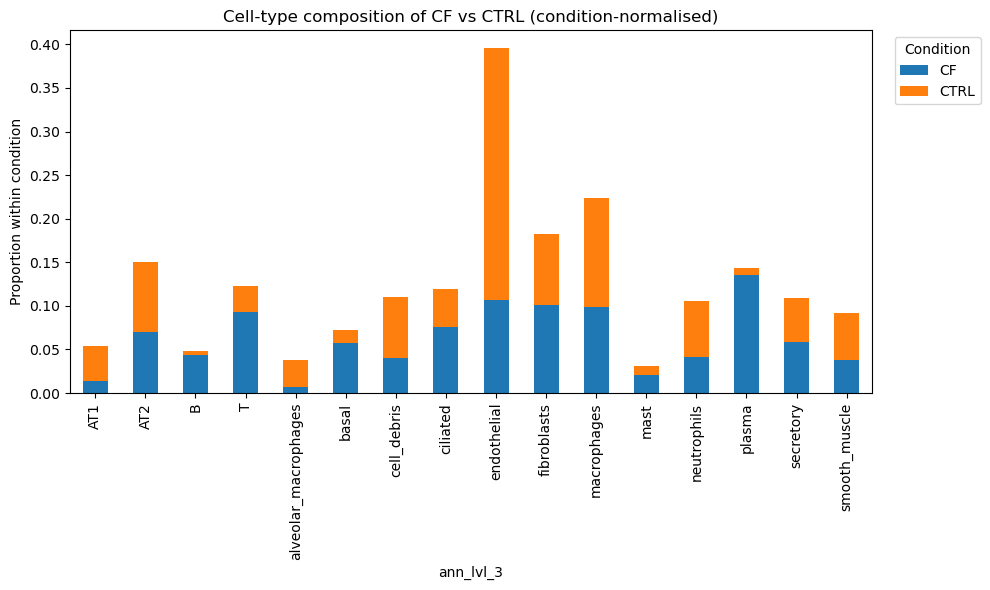

In [10]:
import matplotlib.pyplot as plt

ax = condition_norm.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.ylabel("Proportion within condition")
plt.title("Cell-type composition of CF vs CTRL (condition-normalised)")
plt.legend(title="Condition", bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()


per cell type

In [11]:
comb.obs['sample_name'] = comb.obs['sample_name'].astype(str)
comb.obs['ct_scANVI'] = comb.obs['ct_scANVI'].astype(str)
comb.obs['ct_resolvi'] = comb.obs['ct_resolvi'].astype(str)
comb.obs['condition'] = comb.obs['condition'].astype(str)


In [12]:
import pandas as pd

counts = (
    comb.obs
    #.groupby(['sample_name', 'ct_ResolVI'])
    .groupby(['sample_name', 'ct_scANVI'])
    .size()
    .unstack(fill_value=0)
)


In [13]:
proportions = counts.div(counts.sum(axis=1), axis=0)
proportions


ct_scANVI,AT1,AT2,B,T,alveolar_macrophages,basal,cell_debris,ciliated,endothelial,fibroblasts,macrophages,mast,neutrophils,plasma,secretory,smooth_muscle
sample_name,,,,,,,,,,,,,,,,
CTRL01,0.013357,0.042624,0.022815,0.047003,0.044412,0.037144,0.191846,0.015598,0.119955,0.060995,0.031054,0.009108,0.232889,0.019913,0.041743,0.069545
CTRL02,0.036335,0.117468,0.030602,0.074122,0.065116,0.048285,0.012376,0.065523,0.216304,0.091069,0.055858,0.007476,0.021363,0.014604,0.081714,0.061785
CTRL03,0.025948,0.183757,0.034040,0.037248,0.128511,0.019128,0.013539,0.008354,0.145541,0.105145,0.075363,0.016768,0.048345,0.019976,0.061441,0.076897
CTRL04,0.031510,0.081487,0.012408,0.023315,0.032722,0.076581,0.043052,0.007156,0.179190,0.102551,0.013677,0.017486,0.080102,0.045302,0.100473,0.152989
CTRL05,0.010554,0.026028,0.021988,0.048114,0.031956,0.030458,0.180305,0.013258,0.266630,0.085999,0.020685,0.021337,0.031794,0.035703,0.051762,0.123428
PWCF01_1,0.018404,0.087167,0.093834,0.095402,0.033356,0.022691,0.117915,0.047139,0.077809,0.072510,0.100717,0.014723,0.035113,0.145555,0.013011,0.024654
PWCF01_2,0.006094,0.062146,0.104473,0.059860,0.015937,0.029124,0.042889,0.103762,0.054198,0.066466,0.096495,0.010802,0.029492,0.263686,0.027693,0.026883
PWCF02,0.006910,0.079215,0.032424,0.076063,0.005454,0.064607,0.040256,0.064669,0.124320,0.148689,0.063413,0.019271,0.059851,0.135309,0.024529,0.055020
PWCF03,0.003546,0.028220,0.043470,0.112686,0.009183,0.141713,0.015401,0.118677,0.084284,0.092720,0.040263,0.035992,0.020886,0.147010,0.064530,0.041418


In [14]:
meta = comb.obs[['sample_name', 'condition']].drop_duplicates().set_index('sample_name')
meta

,condition
sample_name,
CTRL01,CTRL
PWCF01_1,CF
PWCF05,CF
PWCF02,CF
PWCF03,CF
PWCF04,CF
CTRL05,CTRL
CTRL02,CTRL
CTRL03,CTRL


In [15]:
print(meta.index)
print(proportions.index)

Index(['CTRL01', 'PWCF01_1', 'PWCF05', 'PWCF02', 'PWCF03', 'PWCF04', 'CTRL05',
       'CTRL02', 'CTRL03', 'CTRL04', 'PWCF01_2', 'PWCF06'],
      dtype='object', name='sample_name')
Index(['CTRL01', 'CTRL02', 'CTRL03', 'CTRL04', 'CTRL05', 'PWCF01_1',
       'PWCF01_2', 'PWCF02', 'PWCF03', 'PWCF04', 'PWCF05', 'PWCF06'],
      dtype='object', name='sample_name')


In [16]:
proportions = proportions.merge(meta, left_index=True, right_index=True)

In [17]:
df = proportions.reset_index()

df_melt = df.melt(
    id_vars=['sample_name', 'condition'],
    var_name='cell_type',
    value_name='proportion'
)


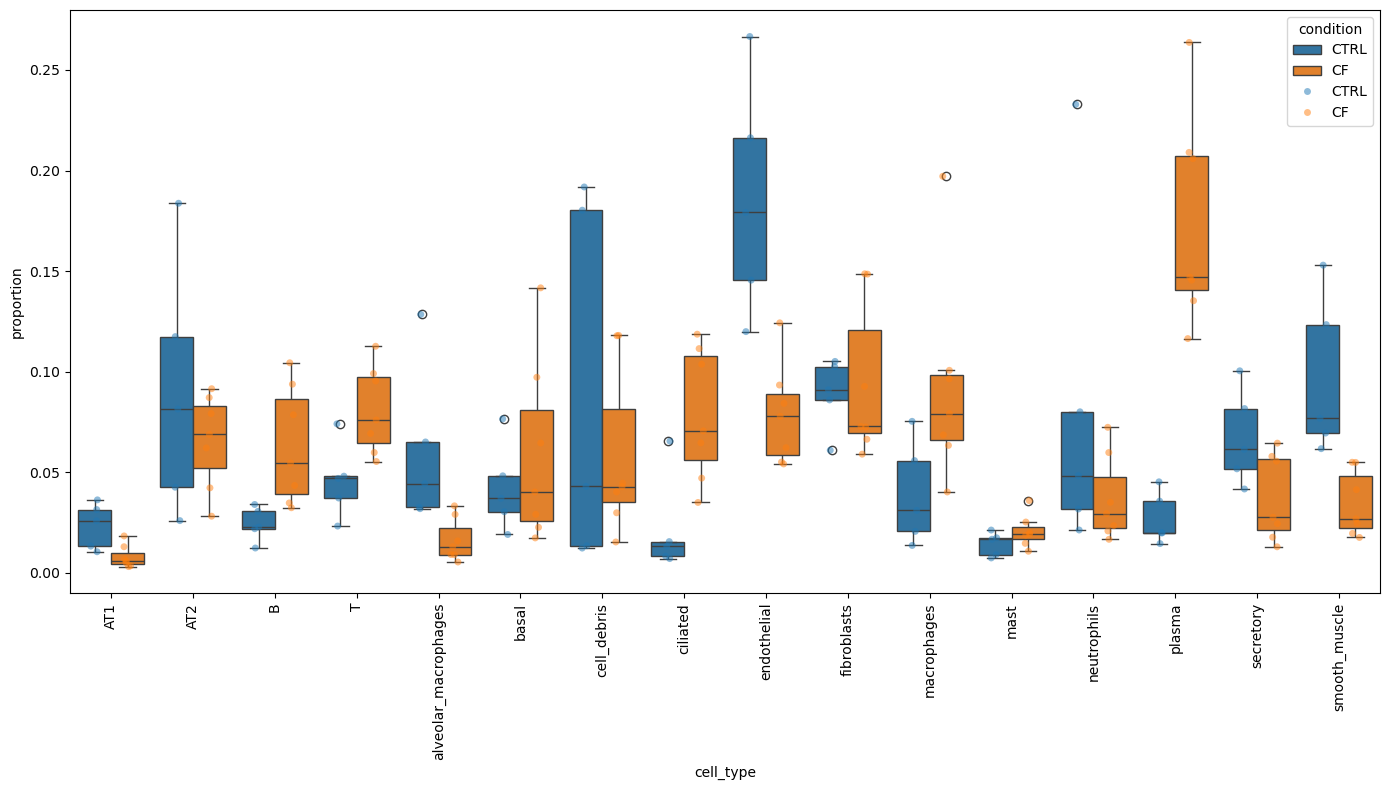

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))
sns.boxplot(
    data=df_melt,
    x='cell_type',
    y='proportion',
    hue='condition'
)
sns.stripplot(
    data=df_melt,
    x='cell_type',
    y='proportion',
    hue='condition',
    dodge=True,
    alpha=0.5
)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))
sns.boxplot(
    data=df_melt,
    x='cell_type',
    y='proportion',
    hue='condition'
)
sns.stripplot(
    data=df_melt,
    x='cell_type',
    y='proportion',
    hue='condition',
    dodge=True,
    alpha=0.5
)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [ ]:
df

anova

In [ ]:
df['condition'] = df['condition'].astype(str)


In [ ]:
from scipy import stats
import pandas as pd

cell_types = [c for c in df.columns if c not in ['sample_name', 'condition']]

results = []

for ct in cell_types:
    # split per condition
    cf_vals   = df.loc[df['condition'] == 'CF',   ct].values
    ctrl_vals = df.loc[df['condition'] == 'CTRL', ct].values
    
    # run ANOVA
    f_stat, p_val = stats.f_oneway(cf_vals, ctrl_vals)
    
    results.append({
        'cell_type': ct,
        'F': f_stat,
        'p_value': p_val
    })

anova_results = pd.DataFrame(results)
anova_results



In [ ]:
from statsmodels.stats.multitest import multipletests

# adjust p-values (FDR)
anova_results['p_adj'] = multipletests(anova_results['p_value'], 
                                       method='fdr_bh')[1]

anova_results.sort_values('p_adj')


In [ ]:
# filter significant results
signif_results = anova_results[anova_results['p_adj'] < 0.05]
signif_results.sort_values('p_adj')

refreshers plots (stacked batplot)

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

# transpose → rows = conditions, columns = cell types
condition_norm.T.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    figsize=(8, 6)
)

plt.ylabel("Proportion of cells")
plt.xlabel("Condition")
plt.title("Cell-type composition per condition")
plt.legend(title="Cell type", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## PseudoBulk

In [ ]:
comb.obs[['sample_name','condition']]

In [ ]:
cell_types = comb.obs['ct_ResolVI'].unique().tolist()
print(cell_types)

In [ ]:
cell_subset = comb[comb.obs['ct_ResolVI'] == 'B']
cell_subset

In [ ]:
pbs = []
for sample in cell_subset.obs.sample_name.unique():
    samp_cell_subset = cell_subset[cell_subset.obs['sample_name'] == sample]
    
    samp_cell_subset.X = samp_cell_subset.layers['counts'] #make sure to use raw data
    
    rep_adata = sc.AnnData(X = samp_cell_subset.X.sum(axis = 0),
                           var = samp_cell_subset.var[[]])
    
    rep_adata.obs_names = [sample]
    rep_adata.obs['condition'] = samp_cell_subset.obs['condition'].iloc[0]
    rep_adata.obs['sample_name'] = sample
    rep_adata.obs['slide_name'] = samp_cell_subset.obs['slide_name'].iloc[0]
    rep_adata.obs['run'] = samp_cell_subset.obs['run'].iloc[0]
    
    pbs.append(rep_adata)

In [ ]:
pbs

In [ ]:
pb = sc.concat(pbs)

In [ ]:
pb.obs

In [ ]:
pb.obs['condition'] = pd.Categorical(
    pb.obs['condition'],
    categories=['CTRL', 'CF'],
    ordered=True
)

In [ ]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

In [ ]:
counts = pd.DataFrame(pb.X, columns = pb.var_names) #need to do this to pass var names

In [ ]:
dds = DeseqDataSet(
    counts = counts,
    metadata=pb.obs,
    design_factors=['run','condition'])

#design_factors=["batch", "condition"] = ~ batch + condtion

In [ ]:
dds

In [ ]:
sc.pp.filter_genes(dds, min_cells = 1)

In [ ]:
dds

In [ ]:
dds.var

In [ ]:
dds.deseq2()

In [ ]:
print(dds.varm["LFC"])

In [ ]:
sc.tl.pca(dds)
sc.pl.pca(dds, color = 'condition', size = 200)

In [ ]:
sc.pl.pca(dds, color = 'run', size = 200)

In [ ]:
stat_res = DeseqStats(dds, n_cpus=32, contrast=('condition', 'CF', 'CTRL'))
    
stat_res.summary()

In [ ]:
de  = stat_res.results_df

In [ ]:
de.sort_values('log2FoldChange', ascending = False)

In [ ]:
stat_res.lfc_shrink(coeff='condition[T.CF]') # only modifies the object in place, beed to get results_df again, change is permanent in the stat_res object

In [ ]:
de_shrink = stat_res.results_df
de_shrink.sort_values('log2FoldChange', ascending = False)
